# ML-CUP – CV + internal test

Minimal notebook to: load config, run 5-fold CV (with per-fold normalization), plot mean±std learning curves, and evaluate MEE in original scale.


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold

from data_handler.data_loader import load_cup, normalize, denormalize
from training.kfold_cv import kfold_cross_validation
from training.trainer import Trainer
from training.model_factory import build_model_from_cfg


In [2]:
# --- Reproducibility ---
SEED = 42
np.random.seed(SEED)


In [3]:
# --- Paths ---
BEST_CFG_PATH = 'experiments/CUP/results/cup_exp_1/best_config.json'
INT_TRAIN_PATH = 'data/CUP/internal_train_90.csv'
INT_TEST_PATH  = 'data/CUP/internal_test_10.csv'

In [4]:
# --- Load best config ---
with open(BEST_CFG_PATH, 'r') as f:
    cfg = json.load(f)

print('Loaded config:', BEST_CFG_PATH)
print('CV:', cfg.get('cv', {}))


Loaded config: experiments/CUP/results/cup_exp_1/best_config.json
CV: {'k': 5, 'seed': 42, 'shuffle': True}


In [5]:
# --- Load raw data ---
X_train_raw, y_train_raw = load_cup(INT_TRAIN_PATH)
X_test_raw,  y_test_raw  = load_cup(INT_TEST_PATH)

in_dim = X_train_raw.shape[1]
out_dim = y_train_raw.shape[1]

print('Train:', X_train_raw.shape, y_train_raw.shape)
print('Test :', X_test_raw.shape, y_test_raw.shape)


Train: (450, 12) (450, 4)
Test : (50, 12) (50, 4)


In [6]:
# --- Build model + trainer ---
model = build_model_from_cfg(
    run_cfg=cfg,
    seed=SEED,
    in_dim=in_dim,
    out_dim=out_dim,
    task='regression',
)
trainer = Trainer(model=model, verbose=True)


In [7]:
# --- K-Fold CV (per-fold normalization inside the function) ---
K_FOLDS = int(cfg.get('cv', {}).get('k', 5))
EPOCHS = int(cfg['training']['epochs'])
BATCH_SIZE = int(cfg['training']['batch_size'])

train_stats, val_stats, histories, fold_results = kfold_cross_validation(
    X=X_train_raw,
    y=y_train_raw,
    model=model,
    trainer=trainer,
    k=K_FOLDS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    verbose=1,
    include_reg_in_val=True,
    normalize_data=True,
    normalize_target=True,
)

print('Train (mean±std):', train_stats)
print('Val   (mean±std):', val_stats)


Task: Regression (y.shape=(450, 4))
Using KFold with k=5

Fold 1/5
------------------------------------------------------------

      _____     ___                 _ _ _ 
      \_   \   / __\__ ___   ____ _| | (_)
       / /\/  / /  / _` \ \ / / _` | | | |
    /\/ /_   / /__| (_| |\ V / (_| | | | |
    \____/   \____/\__,_| \_/ \__,_|_|_|_|
        
Epoch 1000/1000 [==============================>] loss: 1.2124 MEE: 0.9792 val_loss: 1.5850 val_MEE: 1.1541
  Train: loss=1.2118, MEE=0.9790
  Val:   loss=1.5850, MEE=1.1541

Fold 2/5
------------------------------------------------------------
Epoch 63/1000 [=>............................] loss: 2.5874 MEE: 1.4815 val_loss: 2.8626 val_MEE: 1.5636
  Train: loss=2.7460, MEE=1.5411
  Val:   loss=2.8268, MEE=1.5574

Fold 3/5
------------------------------------------------------------
Epoch 1000/1000 [==============================>] loss: 1.1833 MEE: 0.9869 val_loss: 1.7267 val_MEE: 1.1375
  Train: loss=1.1828, MEE=0.9867
  Val:   loss=1.726

In [8]:
# --- Best epoch per fold (min val_loss) ---
best_epochs = []
best_val_losses = []

for i, h in enumerate(histories, start=1):
    val_loss = np.array(h.logs['val_loss'], dtype=float)
    be = int(np.argmin(val_loss)) + 1
    best_epochs.append(be)
    best_val_losses.append(float(val_loss[be - 1]))
    print(f'Fold {i}: best_epoch={be}, best_val_loss={val_loss[be-1]:.6f}')

avg_best_epoch = int(np.mean(best_epochs))
print('-' * 30)
print('Avg best epoch:', avg_best_epoch)
print('Avg best val loss:', float(np.mean(best_val_losses)))


Fold 1: best_epoch=1000, best_val_loss=1.584971
Fold 2: best_epoch=13, best_val_loss=2.826760
Fold 3: best_epoch=1000, best_val_loss=1.726693
Fold 4: best_epoch=600, best_val_loss=2.026211
Fold 5: best_epoch=991, best_val_loss=1.750308
------------------------------
Avg best epoch: 720
Avg best val loss: 1.982988752755719


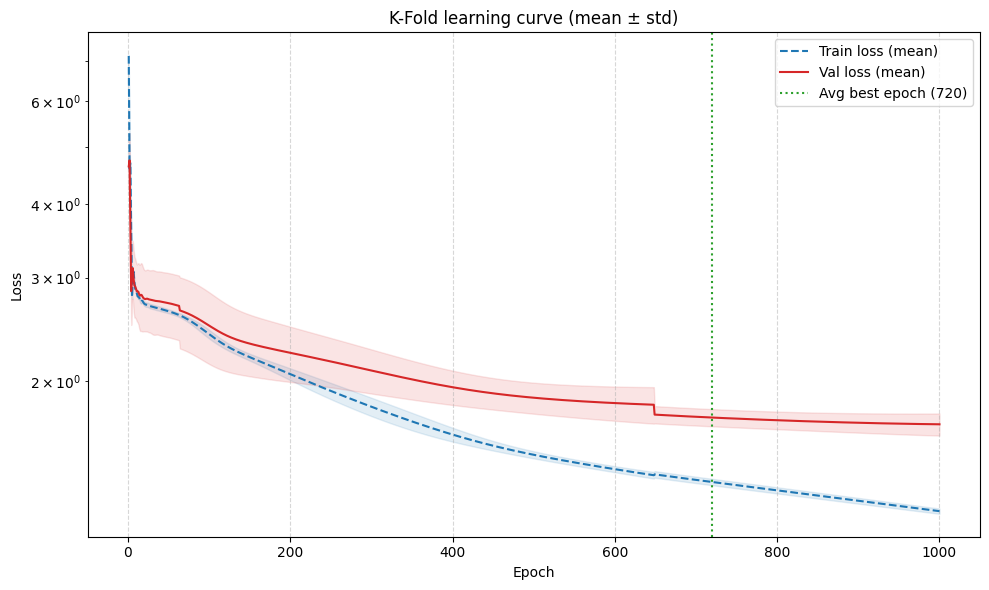

In [9]:
# --- Plot mean±std learning curves (train/val) ---
max_epochs = max(len(h.logs['loss']) for h in histories)

all_train = np.full((len(histories), max_epochs), np.nan)
all_val   = np.full((len(histories), max_epochs), np.nan)

for i, h in enumerate(histories):
    tr = np.array(h.logs['loss'], dtype=float)
    va = np.array(h.logs['val_loss'], dtype=float)
    all_train[i, :len(tr)] = tr
    all_val[i, :len(va)] = va

mean_tr, std_tr = np.nanmean(all_train, axis=0), np.nanstd(all_train, axis=0)
mean_va, std_va = np.nanmean(all_val, axis=0), np.nanstd(all_val, axis=0)

epochs = np.arange(1, max_epochs + 1)
plt.figure(figsize=(10, 6))

plt.plot(epochs, mean_tr, label='Train loss (mean)', color='C0', linestyle='--')
plt.fill_between(epochs, mean_tr - std_tr, mean_tr + std_tr, color='C0', alpha=0.12)

plt.plot(epochs, mean_va, label='Val loss (mean)', color='C3')
plt.fill_between(epochs, mean_va - std_va, mean_va + std_va, color='C3', alpha=0.12)

plt.axvline(avg_best_epoch, color='C2', linestyle=':', label=f'Avg best epoch ({avg_best_epoch})')

plt.title('K-Fold learning curve (mean ± std)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()


Epoch 1000/1000 [==============================>] loss: 1.2124 MEE: 0.9792 val_loss: 2.0199 val_MEE: 1.2884
Epoch 1000/1000 [==============================>] loss: 1.2314 MEE: 0.9858 val_loss: 1.9502 val_MEE: 1.2478
Epoch 1000/1000 [==============================>] loss: 1.1833 MEE: 0.9869 val_loss: 2.0173 val_MEE: 1.2752
Epoch 1000/1000 [==============================>] loss: 1.1226 MEE: 0.9575 val_loss: 2.0389 val_MEE: 1.2873
Epoch 1000/1000 [==============================>] loss: 1.2053 MEE: 0.9854 val_loss: 2.0223 val_MEE: 1.2726


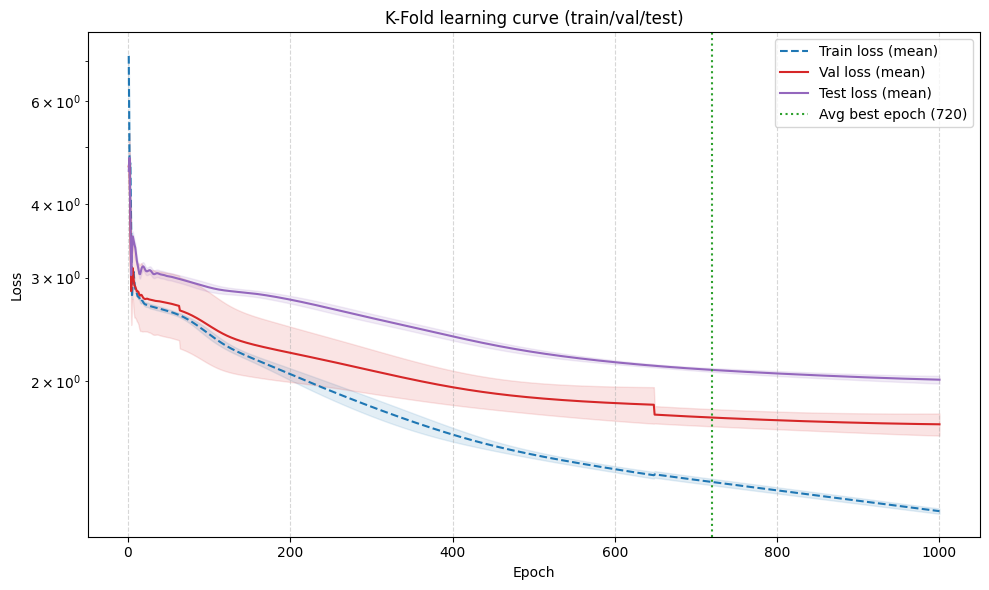

In [ ]:
# --- Add test-loss curve with std (per-fold runs) ---
# This re-trains K models to log test loss as val_loss each epoch.
# Set True if need the shaded test curve.

PLOT_TEST_CURVE = True

if PLOT_TEST_CURVE:
    cv = KFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
    all_test = np.full((K_FOLDS, max_epochs), np.nan)

    # Temporarily disable EarlyStopping to avoid 'monitoring' the test set.
    orig_callbacks = getattr(model, 'callbacks', []) or []
    model.callbacks = [cb for cb in orig_callbacks if cb.__class__.__name__ != 'EarlyStopping']

    for fold_i, (tr_idx, _) in enumerate(cv.split(X_train_raw), start=1):
        X_tr_raw, y_tr_raw = X_train_raw[tr_idx], y_train_raw[tr_idx]

        # Per-fold normalization (train fold stats).
        X_tr, mean_x, std_x = normalize(X_tr_raw)
        y_tr, mean_y, std_y = normalize(y_tr_raw)

        X_te, _, _ = normalize(X_test_raw, mean=mean_x, std=std_x)
        y_te, _, _ = normalize(y_test_raw, mean=mean_y, std=std_y)

        model.reset()
        h_te = trainer.fit(
            X_train=X_tr,
            y_train=y_tr,
            X_val=X_te,
            y_val=y_te,
            epochs=max_epochs,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=SEED + (fold_i - 1),
            include_reg_in_val=True,
        )

        te = np.array(h_te.logs['val_loss'], dtype=float)
        all_test[fold_i - 1, :len(te)] = te

    model.callbacks = orig_callbacks

    mean_te, std_te = np.nanmean(all_test, axis=0), np.nanstd(all_test, axis=0)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, mean_tr, label='Train loss (mean)', color='C0', linestyle='--')
    plt.fill_between(epochs, mean_tr - std_tr, mean_tr + std_tr, color='C0', alpha=0.12)

    plt.plot(epochs, mean_va, label='Val loss (mean)', color='C3')
    plt.fill_between(epochs, mean_va - std_va, mean_va + std_va, color='C3', alpha=0.12)

    plt.plot(epochs, mean_te, label='Test loss (mean)', color='C4')
    plt.fill_between(epochs, mean_te - std_te, mean_te + std_te, color='C4', alpha=0.12)

    plt.axvline(avg_best_epoch, color='C2', linestyle=':', label=f'Avg best epoch ({avg_best_epoch})')
    plt.title('K-Fold learning curve (train/val/test)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.yscale('log')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [11]:
# --- MEE in original scale (train/val per fold + final test) ---
# Note: this re-runs training fold-by-fold because kfold_cross_validation does not return models/indices.

def mee_original(y_true, y_pred):
    return float(np.mean(np.linalg.norm(y_pred - y_true, axis=1)))

cv = KFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

train_mee = []
val_mee = []

print('' + '=' * 70)
print('K-FOLD MEE (original scale)')
print('=' * 70)

for fold_i, (tr_idx, va_idx) in enumerate(cv.split(X_train_raw), start=1):
    X_tr_raw, y_tr_raw = X_train_raw[tr_idx], y_train_raw[tr_idx]
    X_va_raw, y_va_raw = X_train_raw[va_idx], y_train_raw[va_idx]

    X_tr, mean_x, std_x = normalize(X_tr_raw)
    X_va, _, _ = normalize(X_va_raw, mean=mean_x, std=std_x)

    y_tr, mean_y, std_y = normalize(y_tr_raw)
    y_va, _, _ = normalize(y_va_raw, mean=mean_y, std=std_y)

    model.reset()
    trainer.fit(
        X_train=X_tr,
        y_train=y_tr,
        X_val=X_va,
        y_val=y_va,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED + (fold_i - 1),
        include_reg_in_val=True,
    )

    yhat_tr = denormalize(model.predict_proba(X_tr), mean=mean_y, std=std_y)
    yhat_va = denormalize(model.predict_proba(X_va), mean=mean_y, std=std_y)

    m_tr = mee_original(y_tr_raw, yhat_tr)
    m_va = mee_original(y_va_raw, yhat_va)

    train_mee.append(m_tr)
    val_mee.append(m_va)

    print(f'Fold {fold_i}: train_MEE={m_tr:.4f} | val_MEE={m_va:.4f}')

print('-' * 70)
print(f'Train MEE: {np.mean(train_mee):.4f} ± {np.std(train_mee):.4f}')
print(f'Val   MEE: {np.mean(val_mee):.4f} ± {np.std(val_mee):.4f}')

# Final training on full internal train (90%) for avg_best_epoch, then test on internal test (10%).
X_tr_all, mean_x, std_x = normalize(X_train_raw)
y_tr_all, mean_y, std_y = normalize(y_train_raw)
X_te, _, _ = normalize(X_test_raw, mean=mean_x, std=std_x)

model.reset()
trainer.fit(
    X_train=X_tr_all,
    y_train=y_tr_all,
    epochs=avg_best_epoch,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

yhat_te = denormalize(model.predict_proba(X_te), mean=mean_y, std=std_y)
mee_te = mee_original(y_test_raw, yhat_te)
print('-' * 70)
print(f'Test MEE (original scale): {mee_te:.4f}')


K-FOLD MEE (original scale)
Epoch 1000/1000 [==============================>] loss: 1.2124 MEE: 0.9792 val_loss: 1.5850 val_MEE: 1.1541
Fold 1: train_MEE=18.1472 | val_MEE=20.4799
Epoch 63/1000 [=>............................] loss: 2.5874 MEE: 1.4815 val_loss: 2.8626 val_MEE: 1.5636
Fold 2: train_MEE=25.9739 | val_MEE=26.6069
Epoch 1000/1000 [==============================>] loss: 1.1833 MEE: 0.9869 val_loss: 1.7267 val_MEE: 1.1375
Fold 3: train_MEE=18.5238 | val_MEE=20.3931
Epoch 648/1000 [===================>..........] loss: 1.3662 MEE: 1.0483 val_loss: 2.0285 val_MEE: 1.3000
Fold 4: train_MEE=18.9604 | val_MEE=24.1016
Epoch 1000/1000 [==============================>] loss: 1.2053 MEE: 0.9854 val_loss: 1.7503 val_MEE: 1.1888
Fold 5: train_MEE=18.0070 | val_MEE=21.6413
----------------------------------------------------------------------
Train MEE: 19.9225 ± 3.0438
Val   MEE: 22.6445 ± 2.3910
Epoch 720/720 [==============================>] loss: 1.1720 MEE: 0.9709
-----------------

In [18]:
print('-' * 70)
print('Evaluating Ensemble on Internal Test Set...')

N_MODELS = 10  
SEED = 42
ensemble_preds = []

for i in range(N_MODELS):
    seed_i = SEED + i
    print(f"Internal Ensemble - Model {i+1}/{N_MODELS} (Seed: {seed_i})...", end='\r')

   
    model_ens = build_model_from_cfg(
        run_cfg=cfg,
        seed=seed_i,
        in_dim=in_dim,
        out_dim=out_dim,
        task='regression',
    )

    trainer_ens = Trainer(model=model_ens, verbose=False)  

    trainer_ens.fit(
        X_train=X_tr_all,
        y_train=y_tr_all,
        epochs=avg_best_epoch, 
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=seed_i,
    )

    pred_norm = model_ens.predict_proba(X_te)
    ensemble_preds.append(pred_norm)

print(f"\nInternal Ensemble training completed ({N_MODELS} models).")

avg_pred_norm = np.mean(ensemble_preds, axis=0)

yhat_ens_te = denormalize(avg_pred_norm, mean=mean_y, std=std_y)

mee_ens_te = mee_original(y_test_raw, yhat_ens_te)

print(f'Internal Test MEE (Ensemble {N_MODELS} models): {mee_ens_te:.4f}')
print('-' * 70)

----------------------------------------------------------------------
Evaluating Ensemble on Internal Test Set...
Internal Ensemble - Model 10/10 (Seed: 51)...
Internal Ensemble training completed (10 models).
Internal Test MEE (Ensemble 10 models): 21.6432
----------------------------------------------------------------------


# BLIND TEST SET

In [ ]:
import sys
import os

sys.path.append(os.getcwd())

from experiments.CUP import common

CUP_ORIGINAL  = 'data/CUP/ML-CUP25-TR.csv' 
INT_TRAIN     = 'data/CUP/internal_train_90.csv'
INT_TEST      = 'data/CUP/internal_test_10.csv'

In [ ]:

import json

config_path = 'experiments/CUP/results/cup_exp_1/best_config.json'

with open(config_path, 'r') as f:
    best_config = json.load(f)

print("=== MIGLIORI IPERPARAMETRI TROVATI ===")
print(json.dumps(best_config, indent=4))

=== MIGLIORI IPERPARAMETRI TROVATI ===
{
    "callbacks": {
        "early_stopping": true,
        "min_delta": "1e-5",
        "mode": "min",
        "monitor": "val_loss",
        "patience": 50,
        "restore_best_weights": true,
        "verbose": 0
    },
    "cv": {
        "k": 5,
        "seed": 42,
        "shuffle": true
    },
    "data": {
        "inputs": 12,
        "normalize": true,
        "normalize_target": true,
        "targets": 4,
        "train_path": "data/CUP/internal_train_80.csv"
    },
    "model": {
        "activation": "tanh",
        "dropout": 0.0,
        "hidden_units": [
            64,
            32,
            16
        ],
        "output_activation": "linear"
    },
    "optim": {
        "lr": 0.01,
        "momentum": 0.8,
        "name": "sgd"
    },
    "regularizer": {
        "l2": 0.0001
    },
    "seed": 42,
    "split": {
        "stratified": false,
        "val_size": 0.2
    },
    "training": {
        "batch_size": 360,
   

In [ ]:
import numpy as np
from data_handler.data_loader import load_cup, normalize, denormalize


FULL_TRAIN_PATH = 'data/CUP/ML-CUP25-TR.csv'
BLIND_TEST_PATH = 'data/CUP/ML-CUP25-TS.csv'

X_full, y_full = load_cup(FULL_TRAIN_PATH, training=True)

X_blind = load_cup(BLIND_TEST_PATH, training=False)

raw_test_data = np.genfromtxt(BLIND_TEST_PATH, delimiter=',', comments='#')
test_ids = raw_test_data[:, 0].astype(int) # Colonna 0 = ID

print(f"Training Set: {X_full.shape}")
print(f"Blind Test Set: {X_blind.shape} (IDs: {len(test_ids)})")

X_full_norm, mean_x_full, std_x_full = normalize(X_full)
y_full_norm, mean_y_full, std_y_full = normalize(y_full)

X_blind_norm, _, _ = normalize(X_blind, mean=mean_x_full, std=std_x_full)

In [ ]:
from training import model_factory
from training.trainer import Trainer

N_MODELS = 10
BASE_SEED = 42
seeds = [BASE_SEED + i for i in range(N_MODELS)]

ensemble_preds_norm = []

print(f"Training Ensemble ({N_MODELS}) on all dataset...")
print(f"Epochs: {720}")
print("-" * 50)

for i, seed in enumerate(seeds):
    print(f"Training Modello {i+1}/{N_MODELS} (Seed: {seed})...", end=" ")

    current_model = model_factory.build_model_from_cfg(
        run_cfg=best_config,
        seed=seed,            
        in_dim=12,
        out_dim=4,
        task='regression'
    )

    trainer = Trainer(model=current_model, verbose=0) 
    trainer.fit(
        X_train=X_full_norm,
        y_train=y_full_norm,
        epochs=avg_best_epoch, 
        batch_size=best_config['training']['batch_size']
    )

    pred_norm = current_model.predict_proba(X_blind_norm)
    ensemble_preds_norm.append(pred_norm)

print("-" * 50)

avg_pred_norm = np.mean(ensemble_preds_norm, axis=0)

y_blind_pred = denormalize(avg_pred_norm, mean_y_full, std_y_full)

In [ ]:
import time

TEAM_NAME = "iCavalli"  
AUTHORS = "Lorenzo Albani, Tommaso Maitino, Riccardo Roselli"   
DATASET_NAME = "ML-CUP25 v1"
CURRENT_DATE = time.strftime("%d %b %Y") 

OUTPUT_FILENAME = f"iCavalli_ML-CUP25-TS.csv" 

ids_column = test_ids.reshape(-1, 1)
output_matrix = np.hstack([ids_column, y_blind_pred])

header_text = (
    f"# {AUTHORS}\n"
    f"# {TEAM_NAME}\n"
    f"# {DATASET_NAME}\n"
    f"# {CURRENT_DATE}"
)

np.savetxt(
    OUTPUT_FILENAME, 
    output_matrix, 
    delimiter=',', 
    header=header_text, 
    comments='', 
    fmt=['%d'] + ['%.6f']*4 
)

print(f"\nFile ENSEMBLE Saved: {OUTPUT_FILENAME}")


File ENSEMBLE salvato correttamente: iCavalli_ML-CUP25-TS.csv
